Detect anomaly detection in banking transaction w/ Gaussian modeling  
  
Python 3.14.0

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
path = "/kaggle/input/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection/bank_transactions_data_2.csv"

In [3]:
my_df = pd.read_csv(path)
print(my_df.shape)
print(my_df.columns)
print(f"Number of unique cities: {my_df['Location'].unique().shape[0]}")
print(f"Number of unique DeviceID: {my_df['DeviceID'].unique().shape[0]}")
print(f"Number of unique MerchantID: {my_df['MerchantID'].unique().shape[0]}")
print(my_df['LoginAttempts'].head())

(2512, 16)
Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')
Number of unique cities: 43
Number of unique DeviceID: 681
Number of unique MerchantID: 100
0    1
1    1
2    1
3    1
4    1
Name: LoginAttempts, dtype: int64


For this problem, I want to use 4 features to easily visualize w/ graph.  
The 4 features I am going to use are pairs of DeviceID-MerchantID and Location-LoginAttempts  
  
As printed above, most features contain string or entirely string, so I will have to map them w/ unique numbers

In [4]:
# Clean data
filtered_df = my_df[[
    'Location',
    'DeviceID',
    'MerchantID',
    'LoginAttempts'
]]
filtered_df = filtered_df[
    filtered_df['Location'].notna() &
    filtered_df['DeviceID'].notna() &
    filtered_df['MerchantID'].notna() &
    filtered_df['LoginAttempts'].notna()
]
print(filtered_df.shape)

(2512, 4)


In [5]:
def get_sum_string(string):
    return sum([ord(letter) for letter in string])

In [6]:
# Numerical maps
location_map = {}
location_counter = 0
for location in filtered_df['Location']:
    if location not in location_map:
        location_map[location] = location_counter
        location_counter += 1
    
device_map = {}
for device_id in filtered_df['DeviceID']:
    device_sum = get_sum_string(device_id)
    if device_id not in device_map:
        device_map[device_id] = device_sum

merchant_map = {}
for merchant_id in filtered_df['MerchantID']:
    merchant_sum = get_sum_string(merchant_id)
    if merchant_id not in merchant_map:
        merchant_map[merchant_id] = merchant_sum

# Mapping to numerical columns
filtered_df['int_Location'] = [location_map[location] for location in filtered_df['Location']]
filtered_df['int_DeviceID'] = [device_map[device_id] for device_id in filtered_df['DeviceID']]
filtered_df['int_MerchantID'] = [merchant_map[merchant_id] for merchant_id in filtered_df['MerchantID']]

In [7]:
# Splitting data
X_train, X_test = train_test_split(filtered_df, train_size=.8, random_state=42)
X_train = np.array(X_train)
X_test = np.array(X_test)

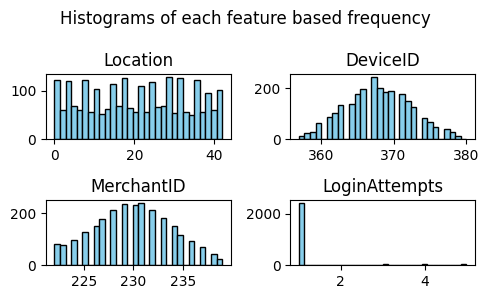

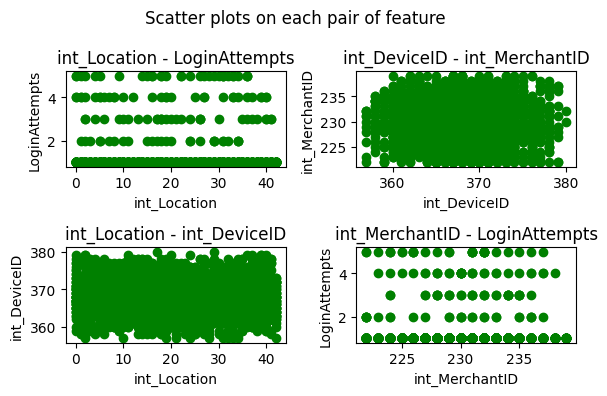

In [8]:
# Initial plot
def output_graph(df):
    # Histograms
    fig1, axes = plt.subplots(2, 2, figsize=(5, 3))
    fig1.suptitle("Histograms of each feature based frequency")
    columns = ["int_Location", "int_DeviceID", "int_MerchantID", "LoginAttempts"]
    for ax, col in zip(axes.flatten(), columns):
        ax.hist(df[col], bins=30, color="skyblue", edgecolor="black")
        ax.set_title(col[4:])
    plt.tight_layout()
    plt.title(col)
    plt.show()

    fig2, axes = plt.subplots(2, 2, figsize=(6, 4))
    fig2.suptitle("Scatter plots on each pair of feature")
    pairs = [
        ("int_Location", "LoginAttempts"),
        ("int_DeviceID", "int_MerchantID"),
        ("int_Location", "int_DeviceID"),
        ("int_MerchantID", "LoginAttempts"),
    ]
    for ax, (xcol, ycol) in zip(axes.flatten(), pairs):
        ax.scatter(df[xcol], df[ycol], marker='o', c='green')
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_title(f"{xcol} - {ycol}")
    plt.tight_layout()
    plt.show()

output_graph(filtered_df)

### Anomaly detection algorithm

In [9]:
# Variables and parameters

numerical_df = filtered_df[[
    'int_Location',
    'int_DeviceID',
    'int_MerchantID',
    'LoginAttempts'
]]
epsilon = 1e-10

In [10]:
def probability(X):
    means = np.mean(X, axis=0)
    std_dev = np.std(X, axis=0)
    variance = std_dev**2
    p = (1 / (np.sqrt(2 * np.pi) * std_dev)) * np.exp(-(np.array(numerical_df) - means)**2 / (2 * variance))
    p_x = np.prod(p, axis=1)
    return p_x

In [11]:
# Probability
p_x = probability(np.array(numerical_df))

In [12]:
test_prop = (p_x <= epsilon)
print(f"Fraud detected on test: {np.sum(test_prop)}")
print(np.where(test_prop == 1))

Fraud detected on test: 33
(array([  26,  147,  274,  394,  414,  463,  491,  508,  551,  685,  691,
        693,  792,  953,  961, 1042, 1121, 1136, 1213, 1283, 1363, 1557,
       1584, 1731, 1774, 1801, 1884, 1969, 2006, 2073, 2159, 2161, 2310]),)


Even though it has detected 'potential fraud' examples. I am not sure if these examples are fraud since the dataset does not provide labels to check. However, the implementation is from the book and ensure to work efficiently.